# create mask for Ross Sea regions on CESM HR grid
# resulting mask includes "wider Ross Sea region" which is user defined (in case the 'outside of MPA' region should be a little larger). Here, wider Ross Sea region set to range to 135°E and to 135°W on each side of the dateline

In [1]:
import os
from tqdm import tqdm
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from netCDF4 import Dataset, MFDataset
from matplotlib.path import Path as MplPath
from shapely.ops import transform as shapely_transform
from matplotlib.colors import ListedColormap
from cartopy.io import shapereader
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.patches import Patch

In [2]:
%%time
#---
# load CESM lat/lon data
#---

vari1 = 'totChl'
path1 = '/global/cfs/cdirs/m4839/cnissen/CESM_HIGH_RES_RossSea/'
file1 = 'CESM_HR_totChl_surface_SO_daily_1997_2021.nc' # could be replaced with output file (used to load lat/lon)

year_list = np.arange(1998,1998+1,1) #2021+1,1)

#---
# load lat/lon info
#---

ff  = xr.open_dataset(path1+file1)
lat = ff['latitude'][:,:].values  # Note CN: the file I load here was reduced to the Southern Ocean; lat/lon are masked
lon = ff['longitude'][:,:].values 
ff.close()
print(np.nanmin(lon),np.nanmax(lon))
print(lat.shape,lon.shape)


0.05 359.95
(700, 3600) (700, 3600)
CPU times: user 23.7 ms, sys: 47.6 ms, total: 71.3 ms
Wall time: 95.9 ms



Original CRS: EPSG:6932
lon/lat bounds: -1654904.4576999974 -3309819.551099999 1654909.775100002 -453731.17962600105



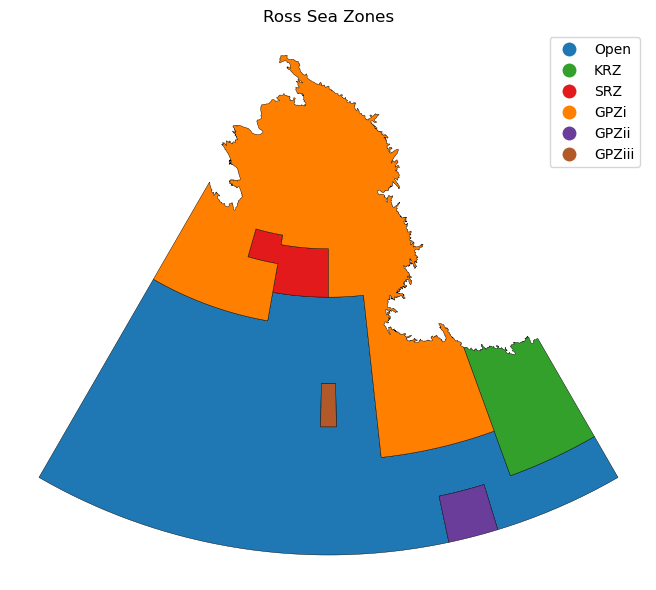

In [3]:
#---
# load shape file for MPA regions, plot here, convert to model grid below
#---

# Name of the column that holds the zone labels
zone_col = "Zone"   # change to your actual column name if different

# Define the order of zones and colors you want to use
zone_order = ['Open', 'KRZ', 'SRZ', 'GPZi', 'GPZii', 'GPZiii']
colors = ['#1f78b4',  # Open
          '#33a02c',  # KRZ
          '#e31a1c',  # SRZ
          '#ff7f00',  # GPZi
          '#6a3d9a',  # GPZii
          '#b15928']  # GPZiii

shp_path = '/global/cfs/cdirs/m4839/cnissen/CESM_HIGH_RES_RossSea/Q_Emp_zone_Map.shp'
gdf = gpd.read_file(shp_path)

print()
minx, miny, maxx, maxy = gdf.total_bounds  # Ross Sea polygon bounds
print("Original CRS:", gdf.crs)
print('lon/lat bounds:',minx, miny, maxx, maxy)
print()

#----
# plot all zones before reprojection
#----

# Ensure the column is a categorical with a fixed order
gdf[zone_col] = pd.Categorical(gdf[zone_col],
                               categories=zone_order,
                               ordered=True)

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
gdf.plot(
    column=zone_col,
    ax=ax,
    categorical=True,
    cmap=ListedColormap(colors),
    legend=True,
    edgecolor='black',
    linewidth=0.3
)
ax.set_title("Ross Sea Zones")
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [4]:
#----
# re-create Ross Sea MPA mask on CESM grid
#----

# functions and some code snippets are from Alexis' scripts
# https://github.com/abahl4/RCN_ModellingStudy/blob/main/scripts/04_zone_timeseries.py

def _get_polys(geom):
    """Recursively extract all Polygon parts from any geometry type."""
    t = geom.geom_type
    if t == 'Polygon':
        return [geom]
    if t in ('MultiPolygon', 'GeometryCollection'):
        result = []
        for g in geom.geoms:
            result.extend(_get_polys(g))
        return result
    return []
    
def _rasterise_wgs84(geom_wgs84) -> np.ndarray:
    """Point-in-polygon rasterisation of a WGS84 shapely geometry.

    Converts geometry to 0-360 longitude, then tests pre-computed Ross Sea
    grid cell centres.  Returns a (N_LAT, N_LON) bool mask.

    Handles multipolygons and interior rings (holes) correctly.
    """
    geom_360 = shapely_transform(lambda x, y: (x % 360, y), geom_wgs84)
    inside = np.zeros(len(_ROSS_POINTS), dtype=bool)

    for poly in _get_polys(geom_360):
        ext_coords = np.array(poly.exterior.coords)[:, :2]
        path_ext   = MplPath(ext_coords)
        mask_poly  = path_ext.contains_points(_ROSS_POINTS)

        for interior in poly.interiors:
            int_coords = np.array(interior.coords)[:, :2]
            mask_poly &= ~MplPath(int_coords).contains_points(_ROSS_POINTS)

        inside |= mask_poly
    print(inside)

    mask_sub  = inside.reshape(N_LAT, _N_ROSS_LON)
    full_mask = np.zeros((N_LAT, N_LON), dtype=bool)
    #full_mask[:, _ROSS_COL_IDX] = mask_sub
    full_mask[:, :] = mask_sub
    return full_mask

# Name of the column that holds the zone labels
zone_col = "Zone"   # change to your actual column name if different

# some settings (needed for Alexis' functions)
_ROSS_POINTS = np.column_stack([lon.ravel(),lat.ravel()]) 
N_LAT        = lon.shape[0]
_N_ROSS_LON  = lon.shape[1]
N_LON        = lon.shape[1]

# convert to lat/lon
gdf_wgs84 = gdf.to_crs("EPSG:4326")
bb = gdf_wgs84.total_bounds   # [minx, miny, maxx, maxy]
print(f"  Reprojected to WGS84.  Bounding box: "
        f"lon [{bb[0]:.3f}, {bb[2]:.3f}]  lat [{bb[1]:.3f}, {bb[3]:.3f}]")

mask_rs = {}
MPA_ZONE_COLUMN = "Zone"
SHP_TO_ZONE     = {'GPZi': 'GPZi', 'GPZii': 'GPZii', 'GPZiii': 'GPZiii',
               'SRZ': 'SRZ', 'KRZ': 'KRZ', 'Open': 'Outside_MPA'}

print("\n  Rasterising shapefile zones …")
for shp_val, zone_key in SHP_TO_ZONE.items():
    rows = gdf_wgs84[gdf_wgs84[MPA_ZONE_COLUMN] == shp_val]
    if len(rows) == 0:
        print(f"    [WARN] '{shp_val}' not found — {zone_key} mask will be empty")
        mask_rs[zone_key] = np.zeros((N_LAT, N_LON), dtype=bool)
    else:
        geom = rows.geometry.union_all()
        mask_rs[zone_key] = _rasterise_wgs84(geom)
        print(f"    {zone_key:<12} ({shp_val}): {mask_rs[zone_key].sum():,} px")

print('done')


  Reprojected to WGS84.  Bounding box: lon [-180.000, 180.000]  lat [-85.412, -60.000]

  Rasterising shapefile zones …
[False False False ... False False False]
    GPZi         (GPZi): 68,760 px
[False False False ... False False False]
    GPZii        (GPZii): 2,600 px
[False False False ... False False False]
    GPZiii       (GPZiii): 1,060 px
[False False False ... False False False]
    SRZ          (SRZ): 8,060 px
[False False False ... False False False]
    KRZ          (KRZ): 14,943 px
[False False False ... False False False]
    Outside_MPA  (Open): 121,602 px
done


100%|██████████| 6/6 [00:00<00:00, 2390.14it/s]


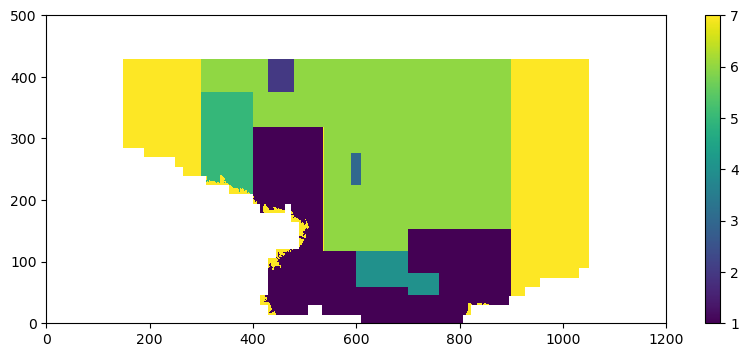

(700, 3600)


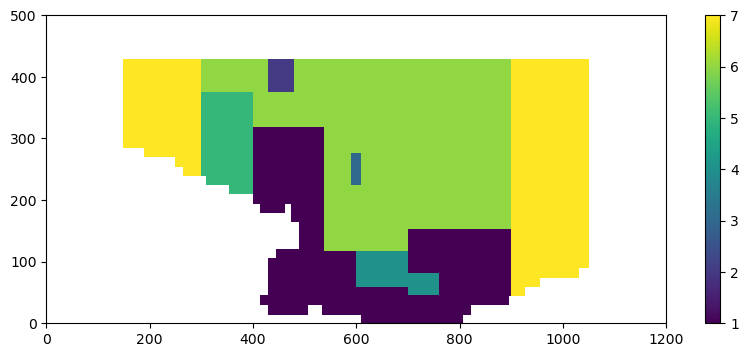

In [10]:
#----
# construct one mask containing all small masks in one
#----

test_plots = True # no projection etc.

zones = ['GPZi','GPZii','GPZiii','SRZ','KRZ','Outside_MPA']

mask_all = np.nan*np.ones_like(lat)
for rr in tqdm(range(0,len(zones))):
    mask_all[mask_rs[zones[rr]]] = rr+1

# add some more masks identifiers for the wider Ross Sea region and the area outside of the Ross Sea
ROSS_LAT_MIN = -80.0
ROSS_LAT_MAX = -60.0
rs_limit1 = 135 # east
rs_limit2 = 135 # west
ROSS_LON_A   =  rs_limit1 #54.9      # lon > ROSS_LON_A  →  east of dateline (~155°E–180°)
ROSS_LON_B   = 180+(180-rs_limit2) #139.9)   # lon < ROSS_LON_B  →  west of dateline (180°–~140°W)
ind = np.where((lat>=ROSS_LAT_MIN) & (lat<=ROSS_LAT_MAX) & (lon<=ROSS_LON_B) & (lon>=ROSS_LON_A))#[0]
mask_all2 = np.nan*np.ones_like(lat)
mask_all2[ind] = np.nanmax(mask_all)+1
del ind
ind = np.where((mask_all2==7) & np.isnan(mask_all))
mask_all[ind] = np.nanmax(mask_all)+1
del mask_all2,ind

# combine the extra "outside of MPA" with already included "outside MPA"
mask_all[mask_all==np.nanmax(mask_all)+1] = np.nanmax(mask_all)

if test_plots:
    plt.figure(figsize=(10,4))
    plt.pcolor(mask_all[0:500,2300:3500]) #mask_rs['Outside_MPA'])
    plt.colorbar()
    plt.show()

# make some manual correction (MPA mask does not go all the way to the coast in CESM HR mesh)
mask_all[200:250,2300+300:2300+399] = zones.index("KRZ")+1   # should be 5
mask_all[0:220,2300+401:2300+510]   = zones.index("GPZi")+1  # should be 1
mask_all[0:50,2300+800:2300+880]    = zones.index("GPZi")+1  # should be 1
# correct some point along the dateline (currently assigned to nothing, assign to zone 1)
mask_all[118:319,2300+537:2300+538][mask_all[118:319,2300+537:2300+538]==7] = zones.index("GPZi")+1  # should be 1

# mask land
mask_all[np.isnan(lon)] = np.nan

print(mask_all.shape)

if test_plots:
    plt.figure(figsize=(10,4))
    plt.pcolor(mask_all[0:500,2300:3500]) #mask_rs['Outside_MPA'])
    plt.colorbar()
    plt.show()


In [17]:
#---
# save to netcdf
#---
save_netcdf = True

savepath     = '/global/cfs/cdirs/m4839/cnissen/CESM_HIGH_RES_RossSea/'
# check existence of paths
if not os.path.exists(savepath):
    print ('Created '+savepath)
    os.makedirs(savepath)

fv = -999
        
if save_netcdf:
    netcdf_name = 'RSrMPA_mask_on_CESM_HR_grid.nc'
    if not os.path.exists(savepath+netcdf_name):
        print('Create file '+savepath+netcdf_name)
        w_nc_fid = Dataset(savepath+netcdf_name, 'w', format='NETCDF4_CLASSIC')
        w_nc_fid.contact = 'Cara Nissen, c.nissen@uva.nl'
        w_nc_fid.source_for_mask = shp_path
        w_nc_fid.script          = '/global/homes/c/cnissen/scripts/plot_CESM_HR_evaluation_create_RS_MPA_mask.ipynb'
        # create dimension & variable
        w_nc_fid.createDimension('lat', lat.shape[0]) 
        w_nc_fid.createDimension('lon', lat.shape[1]) 
        w_nc_var1 = w_nc_fid.createVariable('mask', 'f8',('lat','lon'),fill_value=fv)
        w_nc_var1.description = 'Mask for subregions of Ross Sea MPA'
        # REGIONS ----- hard-coded ------
        w_nc_var1.regions     = '1=GPZi, 2=GPZii, 3=GPZiii, 4=SRZ, 5=KRZ, 6=outside of MPA, 7=wider Ross Sea region' 
        w_nc_var1.limit_for_wider_RS = str(rs_limit1)+'°E and '+str(rs_limit2)+'°W'
        # zones = ['GPZi','GPZii','GPZiii','SRZ','KRZ','Outside_MPA']
                
        w_nc_var1 = w_nc_fid.createVariable('latitude', 'f4',('lat','lon'),fill_value=fv)
        w_nc_var1.description = 'Latitude of CESM HR grid in Southern Ocean, masked'
        w_nc_var1.units = 'deg N'
        w_nc_var1 = w_nc_fid.createVariable('longitude', 'f4',('lat','lon'),fill_value=fv)
        w_nc_var1.description = 'Longitude of CESM HR grid (0:360), masked'
        w_nc_var1.units = 'deg E'
        
        w_nc_fid.close()

    # set fill value
    mask_all[np.isnan(mask_all)] = fv
    lon[np.isnan(lon)] = fv
    lat[np.isnan(lat)] = fv
    
    # save to file        
    w_nc_fid = Dataset(savepath+netcdf_name, 'r+', format='NETCDF4_CLASSIC') 
    w_nc_fid.variables['mask'][:,:] = mask_all
    w_nc_fid.variables['latitude'][:,:]  = lat
    w_nc_fid.variables['longitude'][:,:]  = lon
    w_nc_fid.close()  
                        
print ('done')
    

Create file /global/cfs/cdirs/m4839/cnissen/CESM_HIGH_RES_RossSea/RSrMPA_mask_on_CESM_HR_grid.nc
done
